# 03 Classification
**ADHD EEG Classification Project**

**Models:** Random Forest, SVM (RBF kernel)  
**Evaluation:** Stratified 5-fold cross-validation, confusion matrix, ROC curve, feature importance

**Input:** `features.csv`  (121 subjects × 171 features) produced by notebook 02

## 0. Imports & Load Features

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
os.makedirs('plots', exist_ok=True)

COLORS = {'ADHD': '#e07b7b', 'Control': '#7bb8e0'}
RANDOM_STATE = 42

# Load feature matrix
df = pd.read_csv('features.csv')
meta_cols = ['label', 'subject']
feature_cols = [c for c in df.columns if c not in meta_cols]

X = df[feature_cols].values
y = (df['label'] == 'ADHD').astype(int).values  # ADHD=1, Control=0

print(f'Feature matrix : {X.shape}')
print(f'ADHD=1: {y.sum()}  |  Control=0: {(y==0).sum()}')

Feature matrix : (121, 171)
ADHD=1: 61  |  Control=0: 60


## 1. Model Definitions

Both models are wrapped in a Pipeline with StandardScaler.  
Scaling is critical for SVM; it doesn't change Random Forest but keeps the pipeline consistent.

In [4]:
rf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    RandomForestClassifier(
                   n_estimators=200,
                   max_depth=None,
                   min_samples_leaf=2,
                   random_state=RANDOM_STATE,
                   n_jobs=-1
               ))
])

svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    SVC(
                   kernel='rbf',
                   C=10,
                   gamma='scale',
                   probability=True,   # needed for ROC curve
                   random_state=RANDOM_STATE
               ))
])

models = {'Random Forest': rf, 'SVM (RBF)': svm}
print('Models defined.')

Models defined.


## 2. Stratified 5-Fold Cross-Validation

With only 121 subjects, we use cross-validation instead of a single train/test split.  
Stratified ensures each fold has ~50% ADHD / 50% Control.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['accuracy', 'f1', 'roc_auc']

results = {}
for name, model in models.items():
    print(f'Evaluating {name}...')
    cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring, return_train_score=False)
    results[name] = {
        'accuracy': cv_results['test_accuracy'],
        'f1':       cv_results['test_f1'],
        'roc_auc':  cv_results['test_roc_auc']
    }
    print(f"  Accuracy : {cv_results['test_accuracy'].mean():.3f} ± {cv_results['test_accuracy'].std():.3f}")
    print(f"  F1       : {cv_results['test_f1'].mean():.3f} ± {cv_results['test_f1'].std():.3f}")
    print(f"  ROC-AUC  : {cv_results['test_roc_auc'].mean():.3f} ± {cv_results['test_roc_auc'].std():.3f}")
    print()

Evaluating Random Forest...
  Accuracy : 0.686 ± 0.042
  F1       : 0.700 ± 0.053
  ROC-AUC  : 0.754 ± 0.048

Evaluating SVM (RBF)...
  Accuracy : 0.654 ± 0.062
  F1       : 0.651 ± 0.039
  ROC-AUC  : 0.683 ± 0.085



In [6]:
# Summary table
summary_rows = []
for name, res in results.items():
    summary_rows.append({
        'Model':    name,
        'Accuracy': f"{res['accuracy'].mean():.3f} ± {res['accuracy'].std():.3f}",
        'F1':       f"{res['f1'].mean():.3f} ± {res['f1'].std():.3f}",
        'ROC-AUC':  f"{res['roc_auc'].mean():.3f} ± {res['roc_auc'].std():.3f}"
    })
pd.DataFrame(summary_rows).set_index('Model')

,Accuracy,F1,ROC-AUC
Model,,,
Random Forest,0.686 ± 0.042,0.700 ± 0.053,0.754 ± 0.048
SVM (RBF),0.654 ± 0.062,0.651 ± 0.039,0.683 ± 0.085


## 3. Confusion Matrix & ROC Curve

Fit each model on the full dataset for final evaluation plots.  
> Note: these plots use the full dataset fit. For final performance, always refer to cross-validation scores above.

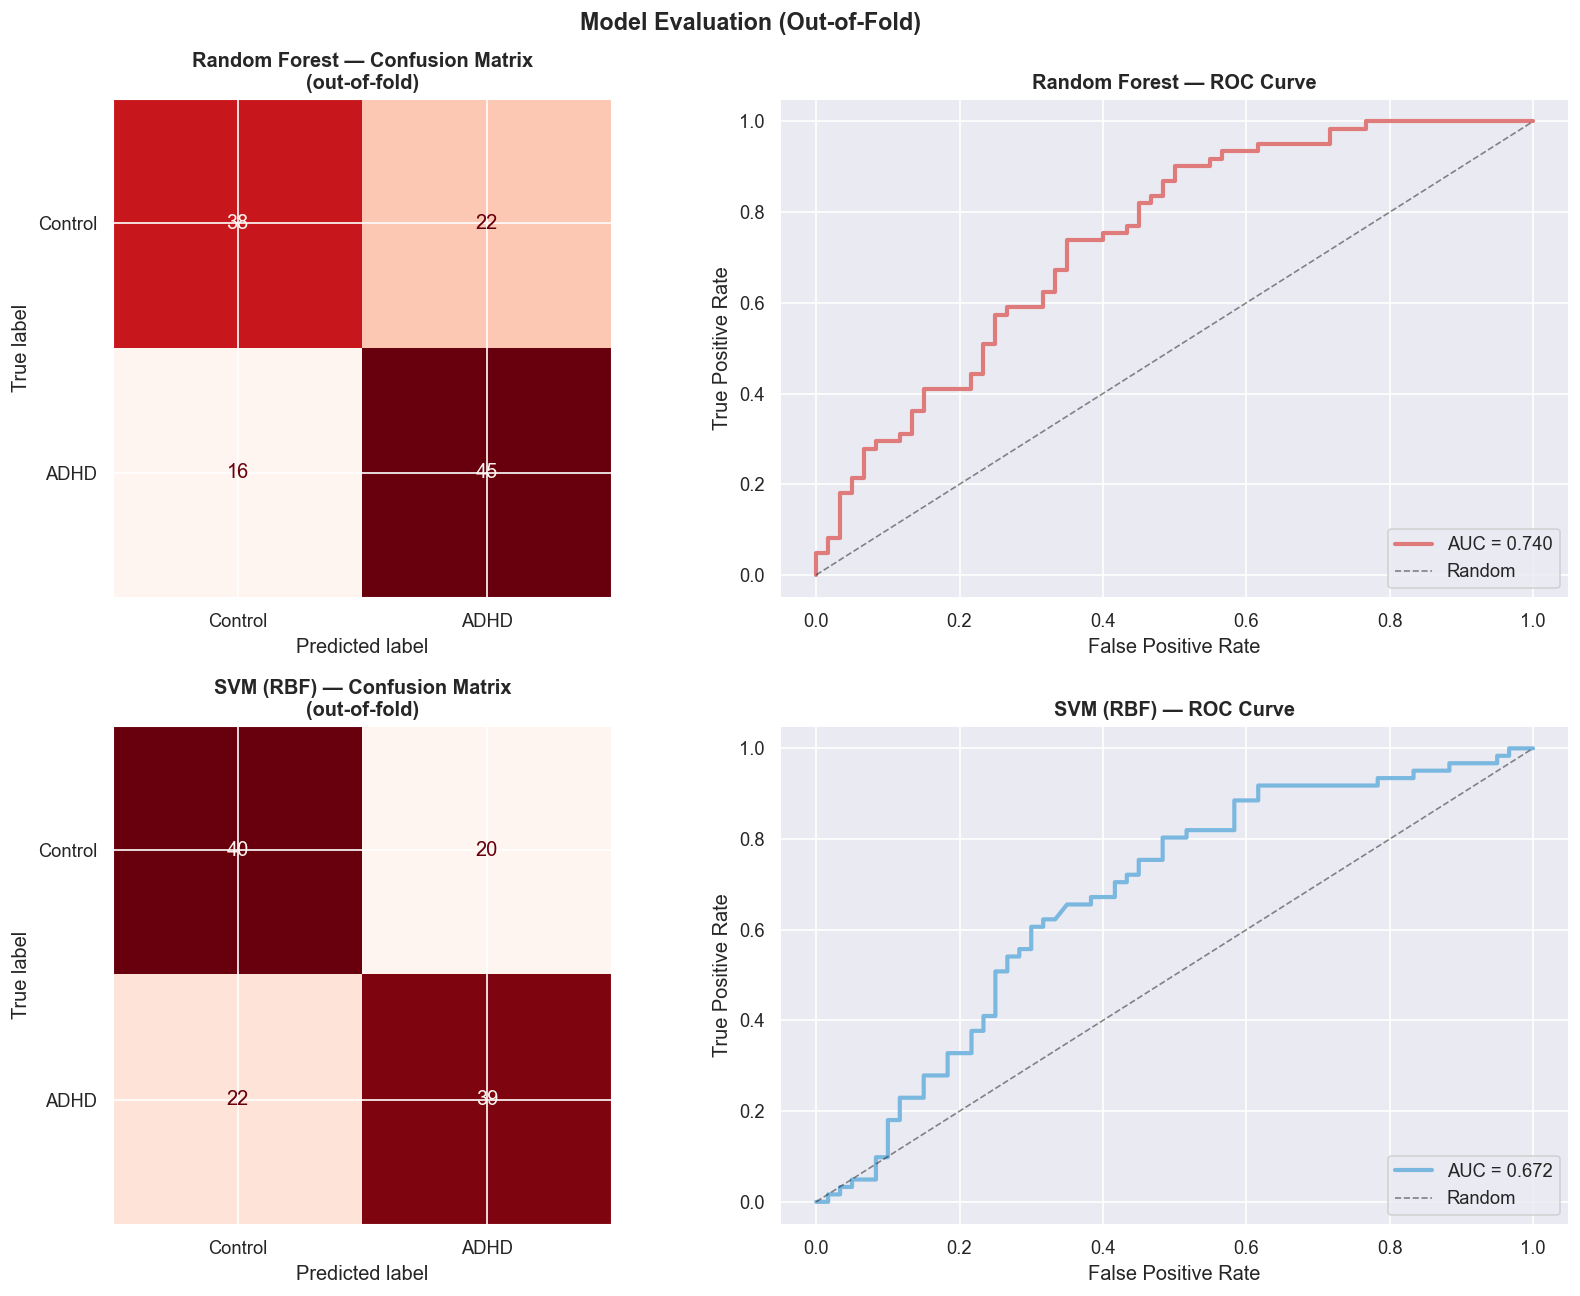

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
model_colors = {'Random Forest': '#e07b7b', 'SVM (RBF)': '#7bb8e0'}

for row_idx, (name, model) in enumerate(models.items()):
    # Collect predictions across folds (proper out-of-fold evaluation)
    y_pred_all  = np.zeros(len(y), dtype=int)
    y_prob_all  = np.zeros(len(y))

    for train_idx, test_idx in cv.split(X, y):
        model.fit(X[train_idx], y[train_idx])
        y_pred_all[test_idx] = model.predict(X[test_idx])
        y_prob_all[test_idx] = model.predict_proba(X[test_idx])[:, 1]

    # Confusion matrix
    ax_cm = axes[row_idx][0]
    cm = confusion_matrix(y, y_pred_all)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Control', 'ADHD'])
    disp.plot(ax=ax_cm, colorbar=False, cmap='Reds')
    ax_cm.set_title(f'{name} — Confusion Matrix\n(out-of-fold)', fontweight='bold')

    # ROC curve
    ax_roc = axes[row_idx][1]
    fpr, tpr, _ = roc_curve(y, y_prob_all)
    auc = roc_auc_score(y, y_prob_all)
    ax_roc.plot(fpr, tpr, color=model_colors[name], linewidth=2.5,
                label=f'AUC = {auc:.3f}')
    ax_roc.plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5, label='Random')
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.set_title(f'{name} — ROC Curve', fontweight='bold')
    ax_roc.legend(loc='lower right')

plt.suptitle('Model Evaluation (Out-of-Fold)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/07_confusion_roc.png', bbox_inches='tight')
plt.show()

## 4. Feature Importance (Random Forest)

Random Forest provides built-in feature importance via mean decrease in impurity.  
We plot the **top 20 features**  

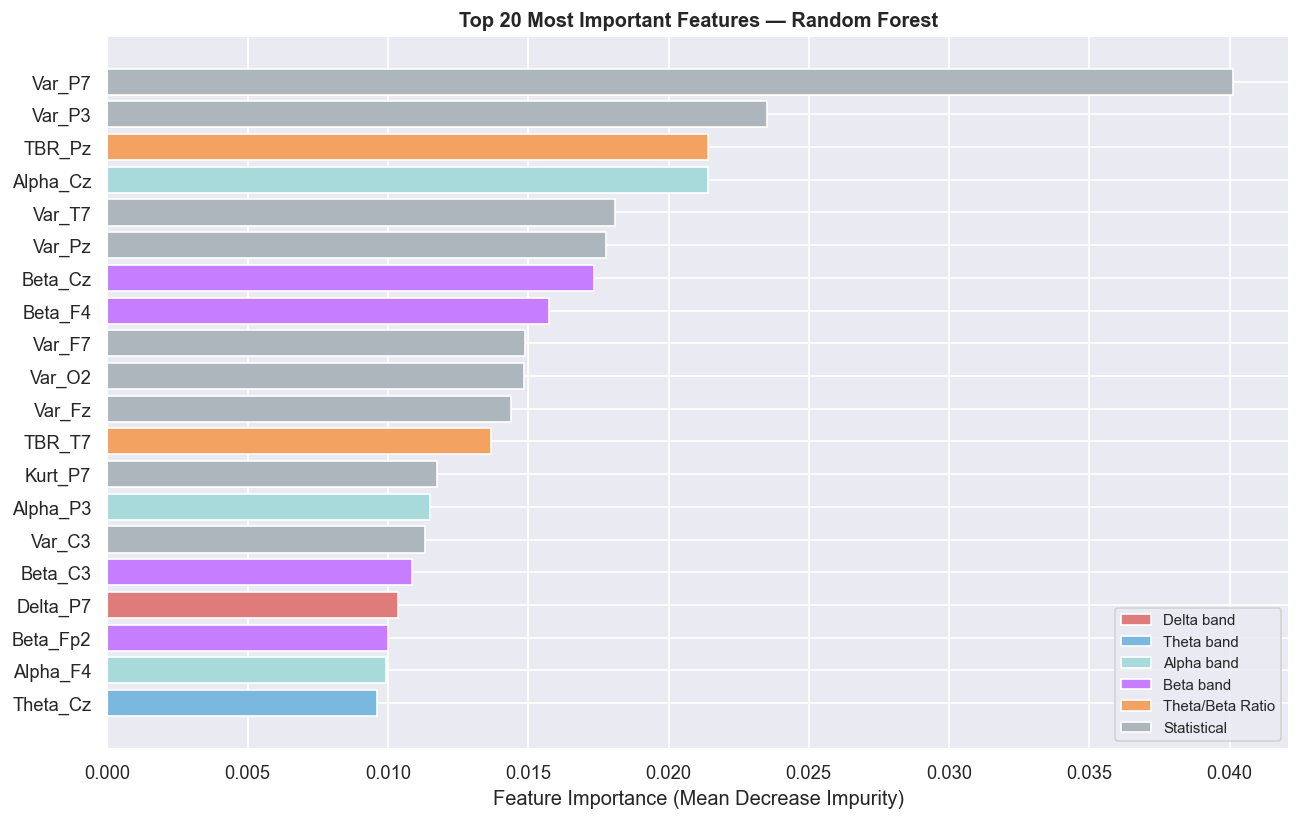

Top 10 features:
 feature  importance
  Var_P7    0.040102
  Var_P3    0.023514
  TBR_Pz    0.021425
Alpha_Cz    0.021394
  Var_T7    0.018076
  Var_Pz    0.017756
 Beta_Cz    0.017342
 Beta_F4    0.015736
  Var_F7    0.014880
  Var_O2    0.014862


In [8]:
# Fit RF on full dataset for stable importance estimates
rf.fit(X, y)
importances = rf.named_steps['clf'].feature_importances_

df_imp = pd.DataFrame({
    'feature':    feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False).head(20)

# Color bars by feature type
def feature_color(name):
    if name.startswith('TBR'):   return '#f4a261'
    if name.startswith('Delta'): return '#e07b7b'
    if name.startswith('Theta'): return '#7bb8e0'
    if name.startswith('Alpha'): return '#a8dadc'
    if name.startswith('Beta'):  return '#c77dff'
    return '#adb5bd'  # stats

colors = [feature_color(f) for f in df_imp['feature']]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(df_imp['feature'][::-1], df_imp['importance'][::-1],
               color=colors[::-1], edgecolor='white')
ax.set_xlabel('Feature Importance (Mean Decrease Impurity)')
ax.set_title('Top 20 Most Important Features — Random Forest', fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e07b7b', label='Delta band'),
    Patch(facecolor='#7bb8e0', label='Theta band'),
    Patch(facecolor='#a8dadc', label='Alpha band'),
    Patch(facecolor='#c77dff', label='Beta band'),
    Patch(facecolor='#f4a261', label='Theta/Beta Ratio'),
    Patch(facecolor='#adb5bd', label='Statistical'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('plots/08_feature_importance.png', bbox_inches='tight')
plt.show()

print('Top 10 features:')
print(df_imp[['feature','importance']].head(10).to_string(index=False))

## 5. Final Results Summary

In [9]:
print('='*55)
print('CLASSIFICATION RESULTS SUMMARY')
print('Evaluation: Stratified 5-Fold Cross-Validation')
print('='*55)
for name, res in results.items():
    print(f'\n{name}')
    print(f"  Accuracy : {res['accuracy'].mean():.3f} ± {res['accuracy'].std():.3f}")
    print(f"  F1 Score : {res['f1'].mean():.3f} ± {res['f1'].std():.3f}")
    print(f"  ROC-AUC  : {res['roc_auc'].mean():.3f} ± {res['roc_auc'].std():.3f}")

print(f'\nTop feature : {df_imp.iloc[0]["feature"]}  (importance={df_imp.iloc[0]["importance"]:.4f})')
print(f'\nPlots saved to: plots/')

CLASSIFICATION RESULTS SUMMARY
Evaluation: Stratified 5-Fold Cross-Validation

Random Forest
  Accuracy : 0.686 ± 0.042
  F1 Score : 0.700 ± 0.053
  ROC-AUC  : 0.754 ± 0.048

SVM (RBF)
  Accuracy : 0.654 ± 0.062
  F1 Score : 0.651 ± 0.039
  ROC-AUC  : 0.683 ± 0.085

Top feature : Var_P7  (importance=0.0401)

Plots saved to: plots/
